In [1]:
import os
import numpy as np
import mdtraj as md
import seaborn as sns
import matplotlib.pyplot as plt

PDB_DIR = './PDBs'
REF_NAME = 'PAC5-Rep1-C1-f287.pdb'          # 指定参考结构

# ---------- 1. 读取并只留 A 链 Cα ----------
def load_a_ca(pdb_path):
    t = md.load(pdb_path)
    idx = t.top.select('chainid 0 and name CA')
    return t.atom_slice(idx)

# ---------- 2. 遍历目录拿到所有 pdb 文件 ----------
pdb_files = sorted([f for f in os.listdir(PDB_DIR) if f.lower().endswith('.pdb')])
if REF_NAME not in pdb_files:
    raise RuntimeError(f'Reference PDB "{REF_NAME}" not found in {PDB_DIR}')
n = len(pdb_files)
print(f'Found {n} PDB files: {pdb_files}')

# ---------- 3. 预加载所有结构 ----------
structures = [load_a_ca(os.path.join(PDB_DIR, f)) for f in pdb_files]

# ---------- 4. 统一对齐到参考结构 ----------
ref_idx = pdb_files.index(REF_NAME)
ref_stru = structures[ref_idx]
for k in range(n):
    if k != ref_idx:
        structures[k].superpose(ref_stru)   # 原地对齐

# ---------- 5. 两两 RMSD（此时已全部朝向一致） ----------
rmsd_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(i, n):
        if i == j:
            rmsd_matrix[i, j] = 0.0
        else:
            rmsd_nm = md.rmsd(structures[j], structures[i])
            rmsd_matrix[i, j] = rmsd_nm * 10   # nm → Å
            rmsd_matrix[j, i] = rmsd_matrix[i, j]

# ---------- 6. 保存矩阵 ----------
labels = [f[:-4] for f in pdb_files]
np.savetxt('rmsd_matrix.txt', rmsd_matrix, header=' '.join(labels), fmt='%.8f')

Found 33 PDB files: ['PAC5-Rep1-C1-f287.pdb', 'PAC5-Rep1-C2-f51.pdb', 'PAC5-Rep1-C3-f947.pdb', 'PAC5-Rep2-C1-f39.pdb', 'PAC5-Rep2-C2-f446.pdb', 'PAC5-Rep2-C3-f830.pdb', 'PAC5-Rep3-C1-f624.pdb', 'PAC5-Rep3-C2-f3203.pdb', 'PAC5-Rep3-C3-f4063.pdb', 'PAC5-Rep3-C4-f2061.pdb', 'RNA-Rep1-C1-f282.pdb', 'RNA-Rep1-C2-f905.pdb', 'RNA-Rep1-C3-f335.pdb', 'RNA-Rep2-C1-f40.pdb', 'RNA-Rep2-C2-f280.pdb', 'RNA-Rep2-C3-f505.pdb', 'RNA-Rep2-C4-f728.pdb', 'RNA-Rep3-C1-f58.pdb', 'RNA-Rep3-C2-f884.pdb', 'RNA-Rep3-C3-f4025.pdb', 'RNA-Rep3-C4-f2953.pdb', 'ssDNA-Rep1-C1-f60.pdb', 'ssDNA-Rep1-C2-f200.pdb', 'ssDNA-Rep1-C3-f368.pdb', 'ssDNA-Rep1-C4-f395.pdb', 'ssDNA-Rep2-C1-f56.pdb', 'ssDNA-Rep2-C2-f168.pdb', 'ssDNA-Rep2-C3-f304.pdb', 'ssDNA-Rep2-C4-f514.pdb', 'ssDNA-Rep2-C5-f792.pdb', 'ssDNA-Rep3-C1-f182.pdb', 'ssDNA-Rep3-C2-f867.pdb', 'ssDNA-Rep3-C3-f4710.pdb']


/tmp/ipykernel_3472801/1792391754.py:41: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  rmsd_matrix[i, j] = rmsd_nm * 10   # nm → Å


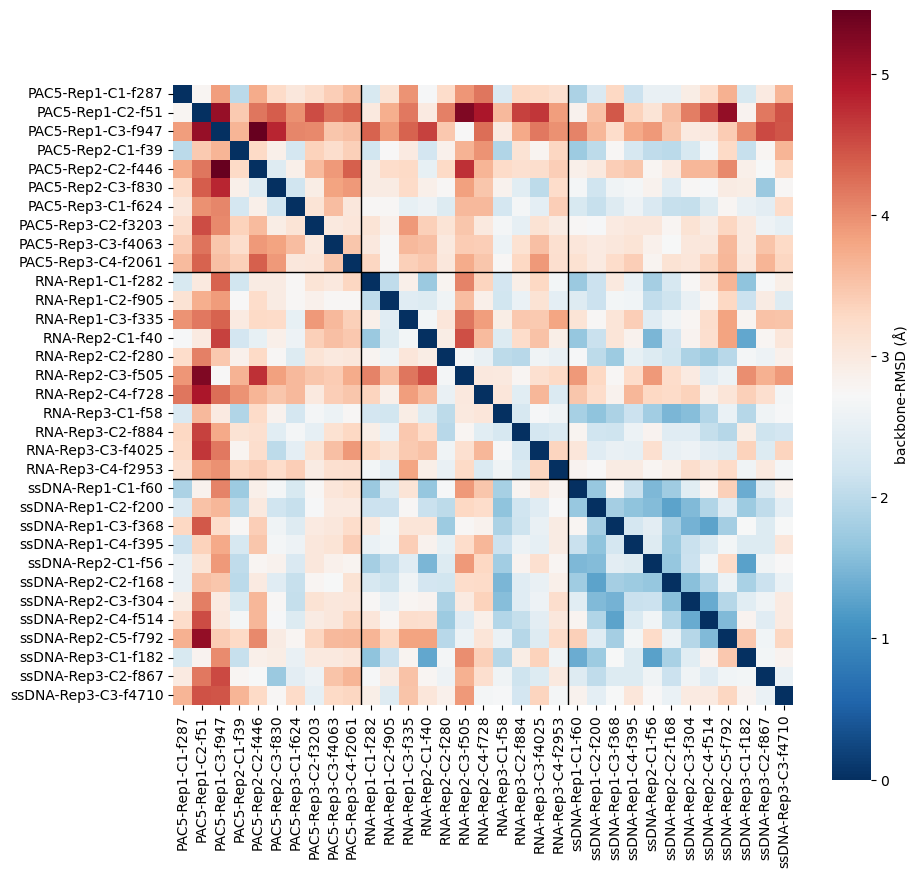

In [4]:
# ---------- 7. 画热图 ----------
plt.figure(figsize=(10, 10))
sns.heatmap(
    rmsd_matrix,
    xticklabels=labels,
    yticklabels=labels,
    cmap='RdBu_r',
    square=True,
    cbar_kws={'label': f'backbone-RMSD (Å)'}
)
plt.axhline(y=10, color='black', linewidth=1)
plt.axhline(y=21, color='black', linewidth=1)
plt.axvline(x=10, color='black', linewidth=1)
plt.axvline(x=21, color='black', linewidth=1)
# plt.tight_layout(rect=[0, 0, 0.93, 1])
plt.savefig('../../Pics/rmsd_heatmap.png', dpi=300)
plt.savefig('../../Pics/rmsd_heatmap.svg', dpi=300)

In [1]:
import pandas as pd

# 读 header（知道列名）
with open('rmsd_matrix.txt') as f:
    header = f.readline().lstrip('#').split()

# 整表读入
df_full = pd.read_csv('rmsd_matrix.txt',
                      sep=r'\s+',
                      comment='#',
                      names=header)

# 前十行 & 第 11 列及以后（索引从 0 开始）
df = df_full.iloc[:10, 10:]      # 行 0-9，列 10-
df.index = header[:10]           # 行名用前 10 个
df

,RNA-Rep1-C1-f282,RNA-Rep1-C2-f905,RNA-Rep1-C3-f335,RNA-Rep2-C1-f40,RNA-Rep2-C2-f280,RNA-Rep2-C3-f505,RNA-Rep2-C4-f728,RNA-Rep3-C1-f58,RNA-Rep3-C2-f884,RNA-Rep3-C3-f4025,...,ssDNA-Rep1-C3-f368,ssDNA-Rep1-C4-f395,ssDNA-Rep2-C1-f56,ssDNA-Rep2-C2-f168,ssDNA-Rep2-C3-f304,ssDNA-Rep2-C4-f514,ssDNA-Rep2-C5-f792,ssDNA-Rep3-C1-f182,ssDNA-Rep3-C2-f867,ssDNA-Rep3-C3-f4710
PAC5-Rep1-C1-f287,2.288424,3.131540,3.957046,2.695017,3.233833,3.930772,4.195416,2.317003,3.295735,3.265302,...,3.297969,2.142297,2.516598,2.535026,2.924500,3.235024,3.686042,2.280812,2.967130,3.653540
PAC5-Rep1-C2-f51,2.991428,3.712459,4.162272,2.964072,4.094628,5.271637,4.949987,3.616063,4.581405,4.676838,...,4.421538,3.345690,3.102046,3.552227,4.125168,4.499648,5.114439,2.822146,4.163894,4.454836
PAC5-Rep1-C3-f947,4.332378,3.877847,4.335793,4.581115,3.457588,2.746513,4.256007,2.962875,3.765136,4.173618,...,3.237395,3.761140,3.907995,3.480235,2.981460,3.009928,3.417274,4.007648,4.525429,4.444721
PAC5-Rep2-C1-f39,2.197050,2.731149,2.971344,2.233331,2.860131,3.680487,3.952140,1.898710,3.129732,2.806492,...,2.754930,2.263419,2.024575,1.988944,2.284994,2.683873,3.271029,2.104220,2.775965,3.648787
PAC5-Rep2-C2-f446,2.945990,3.226401,3.270206,2.505953,3.273218,4.722287,3.653736,3.249779,3.157543,3.209107,...,3.393866,3.492353,2.769754,2.976321,3.638670,3.636505,4.033110,2.895663,2.712634,3.262209
PAC5-Rep2-C3-f830,2.940429,2.940081,3.247795,2.896959,2.764875,3.854068,3.481920,2.835333,2.408399,2.016694,...,2.616961,2.677028,2.841820,2.391007,2.756724,2.703720,2.941809,2.935671,1.719246,2.750321
PAC5-Rep3-C1-f624,2.756476,2.767969,2.509597,2.598026,2.343823,3.607765,3.621387,2.254135,2.682945,2.456730,...,2.371634,2.588875,2.306368,2.107637,2.073746,2.343561,2.769607,2.521336,2.432629,3.238437
PAC5-Rep3-C2-f3203,3.102089,2.868820,3.913192,3.374227,3.104111,3.490390,2.996609,2.679728,2.485061,3.117921,...,2.966142,3.041785,3.027470,2.780567,3.125185,2.949969,3.305033,2.993467,2.590429,2.486611
PAC5-Rep3-C3-f4063,3.013234,2.752205,3.620841,3.540728,2.990459,3.429287,3.391715,2.563715,3.150418,3.550134,...,3.044384,3.097833,2.856743,2.713451,3.036601,3.042558,3.618344,2.995187,3.509718,3.275550
PAC5-Rep3-C4-f2061,3.304167,2.765516,3.375793,3.472054,3.045258,3.728881,3.475735,2.764036,3.286151,3.907777,...,3.237384,3.406161,2.793059,3.119835,3.049487,3.324773,3.624803,3.057025,3.655555,3.319045


In [13]:
row_key  = 'PAC5-Rep2-C3-f830'
col_keys = ['RNA-Rep2-C3-f505', 'ssDNA-Rep3-C2-f867']

df.loc[[row_key], col_keys]

,RNA-Rep2-C3-f505,ssDNA-Rep3-C2-f867
PAC5-Rep2-C3-f830,3.854068,1.719246


In [3]:
import pandas as pd
from scipy import stats

rna_cols  = [c for c in df.columns if c.startswith('RNA')]
ssdna_cols = [c for c in df.columns if c.startswith('ssDNA')]

rna_vals  = df[rna_cols].values.ravel()
ssdna_vals = df[ssdna_cols].values.ravel()

# 独立样本 t 检验（假定方差齐性；若否，加 equal_var=False）
t_stat, p_value = stats.ttest_ind(rna_vals, ssdna_vals, equal_var=True)

print(f'RNA 组样本数 : {len(rna_vals)}')
print(f'ssDNA 组样本数: {len(ssdna_vals)}')
print(f'独立 t 检验 : t = {t_stat:.3f}, p = {p_value:.4g}')
print('显著差异' if p_value < 0.05 else '无显著差异', '(α = 0.05)')

RNA 组样本数 : 110
ssDNA 组样本数: 120
独立 t 检验 : t = 2.960, p = 0.003397
显著差异 (α = 0.05)


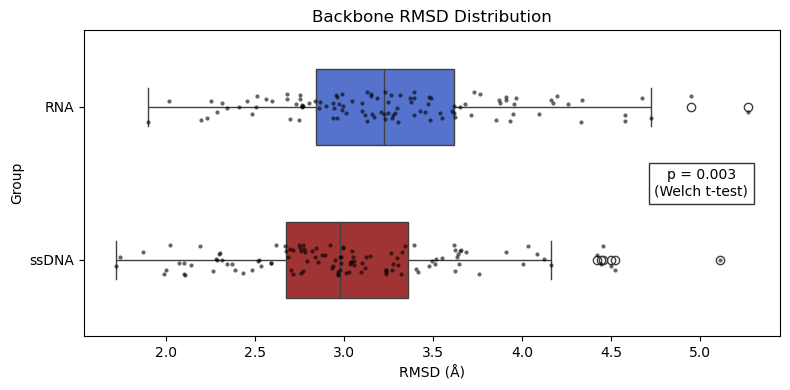

In [11]:
import pandas as pd
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. 数据（已有）
rna_vals   = df[rna_cols].values.ravel()
ssdna_vals = df[ssdna_cols].values.ravel()

# 2. tidy 格式
tidy_df = pd.DataFrame({
    'RMSD (Å)': np.concatenate([rna_vals, ssdna_vals]),
    'Group'   : ['RNA'] * len(rna_vals) + ['ssDNA'] * len(ssdna_vals)
})

# 3. 检验
t_stat, p_value = stats.ttest_ind(rna_vals, ssdna_vals, equal_var=False)

# 4. 水平箱线图
plt.figure(figsize=(8, 4))
sns.boxplot(y='Group', x='RMSD (Å)', data=tidy_df,
            hue='Group',
            palette={'RNA': 'royalblue', 'ssDNA': 'firebrick'},
            width=0.5, orient='h', showfliers=True)

# 均值点
sns.stripplot(y='Group', x='RMSD (Å)', data=tidy_df,
              color='black', size=3, alpha=0.6, dodge=True)

# 标注
plt.text(tidy_df['RMSD (Å)'].max() * 0.95, 0.5,
         f'p = {p_value:.3f}\n(Welch t-test)',
         ha='center', va='center', fontsize=10,
         bbox=dict(boxstyle=None, facecolor='w', alpha=0.8))

plt.title('Backbone RMSD Distribution')
plt.tight_layout()
plt.savefig('../Pics/rna_vs_ssdna_box_horizontal.png', dpi=300)
plt.savefig('../Pics/rna_vs_ssdna_box_horizontal.svg', dpi=300)
plt.show()

In [ ]:
pickFrames = {
    'PAC5' : ('./PDBs/PAC5-Rep2-C3-f830.pdb'),
    'RNA'  : ('./PDBs/RNA-Rep2-C3-f505.pdb'),
    'ssDNA': ('./PDBs/ssDNA-Rep3-C2-f867.pdb')}

In [4]:
import mdtraj as md
import numpy as np
import matplotlib.pyplot as plt

# 1. 文件路径
pickFrames = {
    'PAC5' : './PDBs/PAC5-Rep2-C3-f830.pdb',
    'RNA'  : './PDBs/RNA-Rep2-C3-f505.pdb',
    'ssDNA': './PDBs/ssDNA-Rep3-C2-f867.pdb'
}

# 2. 加载结构（单帧）
pac5 = md.load(pickFrames['PAC5'])
rna  = md.load(pickFrames['RNA'])
dna  = md.load(pickFrames['ssDNA'])

# 3. 选 backbone 原子
backbone_idx = pac5.topology.select('backbone')

# 4. 按残基拆分索引
residue_list = []
for res in pac5.topology.residues:
    res_atoms = [a.index for a in res.atoms if a.index in backbone_idx]
    if res_atoms:                       # 只保留含有 backbone 的残基
        residue_list.append(np.array(res_atoms, dtype=int))

# 5. 计算逐残基 RMSD（nm → Å）
def per_resi_rmsd(ref_traj, mob_traj, res_atom_lists):
    rmsds = []
    for idx in res_atom_lists:
        rmsd = md.rmsd(mob_traj, ref_traj,
                        atom_indices=idx,
                        ref_atom_indices=idx,
                        precentered=False)
        rmsds.append(rmsd[0])      # 单帧，取第 0 帧
    return np.array(rmsds) * 10    # nm → Å

rmsd_rna = per_resi_rmsd(pac5, rna, residue_list)
rmsd_dna = per_resi_rmsd(pac5, dna, residue_list)

# 6. 残基编号
resids = np.array([res.resSeq for res in pac5.topology.residues
                   if any(a.index in backbone_idx for a in res.atoms)])

# 7. 打印差距最大的前 10 个残基
top = 10
print('PAC5 vs RNA — 差距最大残基')
for r, v in zip(resids[np.argsort(rmsd_rna)[::-1][:top]],
                np.sort(rmsd_rna)[::-1][:top]):
    print(f'Res {r}: {v:.2f} Å')

print('\nPAC5 vs ssDNA — 差距最大残基')
for r, v in zip(resids[np.argsort(rmsd_dna)[::-1][:top]],
                np.sort(rmsd_dna)[::-1][:top]):
    print(f'Res {r}: {v:.2f} Å')

PAC5 vs RNA — 差距最大残基
Res 44: 0.70 Å
Res 16: 0.67 Å
Res 41: 0.66 Å
Res 188: 0.63 Å
Res 18: 0.61 Å
Res 193: 0.59 Å
Res 84: 0.58 Å
Res 81: 0.56 Å
Res 192: 0.49 Å
Res 17: 0.48 Å

PAC5 vs ssDNA — 差距最大残基
Res 44: 0.74 Å
Res 41: 0.67 Å
Res 192: 0.46 Å
Res 45: 0.42 Å
Res 137: 0.35 Å
Res 193: 0.30 Å
Res 42: 0.29 Å
Res 132: 0.28 Å
Res 147: 0.23 Å
Res 60: 0.22 Å


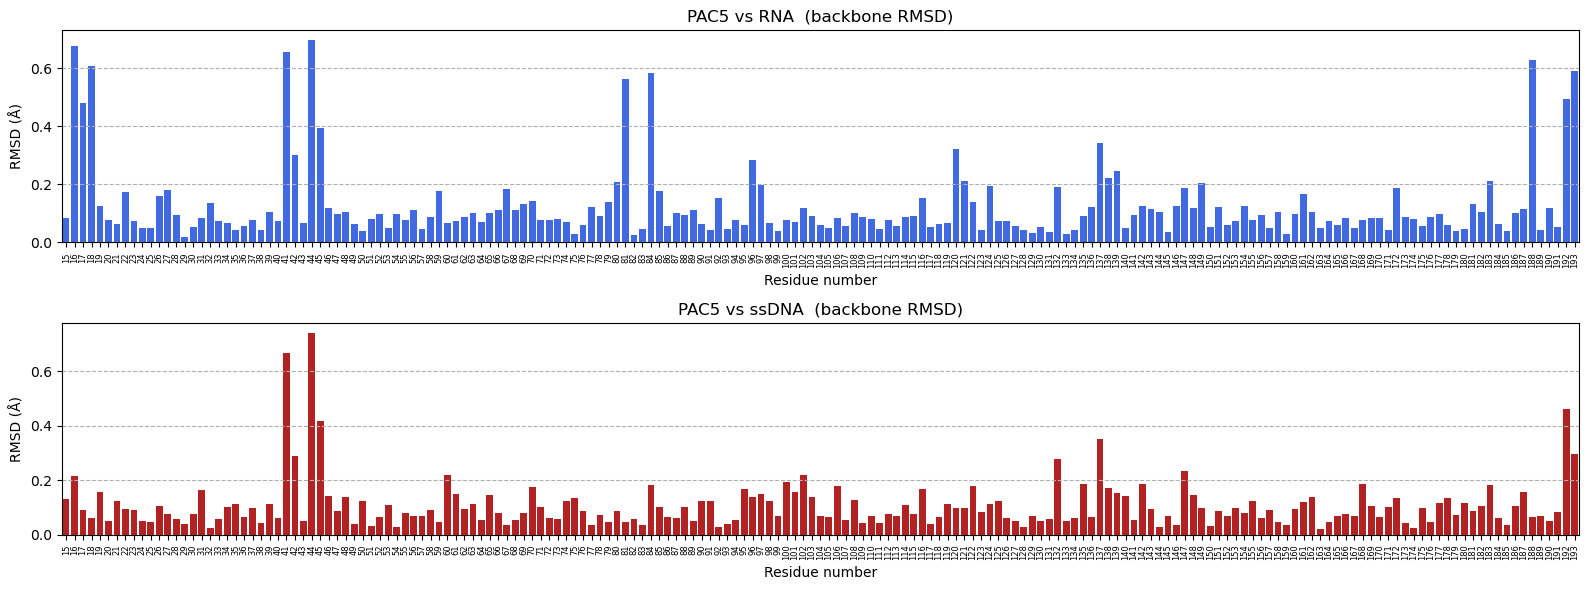

In [5]:
# 0. 只保留 15–193 号残基
mask = (resids >= 15) & (resids <= 193)
plot_res = resids[mask]
plot_rna = rmsd_rna[mask]
plot_dna = rmsd_dna[mask]

# 8. 画图  （不再 sharex，这样两张图都能单独设 xlabel）
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 6))

# === 手动刻度：15–193 全部显示 ===
tick_pos = np.arange(15, 194, 1)
tick_lab = [str(i) for i in tick_pos]

# RNA 子图
ax1.bar(plot_res, plot_rna, color='royalblue')
ax1.set_ylabel('RMSD (Å)')
ax1.set_title('PAC5 vs RNA  (backbone RMSD)')
ax1.set_xticks(tick_pos)
ax1.set_xticklabels(tick_lab, rotation=90, fontsize=6)
ax1.set_xlim(14.5, 193.5)
ax1.set_xlabel('Residue number')   # 关键：给第一张也加 xlabel
ax1.grid(axis='y', ls='--')

# ssDNA 子图
ax2.bar(plot_res, plot_dna, color='firebrick')
ax2.set_xlabel('Residue number')
ax2.set_ylabel('RMSD (Å)')
ax2.set_title('PAC5 vs ssDNA  (backbone RMSD)')
ax2.set_xticks(tick_pos)
ax2.set_xticklabels(tick_lab, rotation=90, fontsize=6)
ax2.set_xlim(14.5, 193.5)
ax2.grid(axis='y', ls='--')

plt.tight_layout()
plt.savefig('pac5_vs_others_resi_rmsd_mdtraj_15-193_fullticks.png', dpi=300)
plt.show()